In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



df = pd.read_csv('IPL.csv')

In [125]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


## Basic information

In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [127]:
# check the size of rows and columns of the dataset
print(f'your rows are {df.shape[0]} and your columns are {df.shape[1]}')

your rows are 74 and your columns are 20


In [128]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

which team won the most matches?

In [129]:
match_wins = df['match_winner'].value_counts()

In [130]:
match_wins

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

Text(0.5, 1.0, 'most match win by a team')

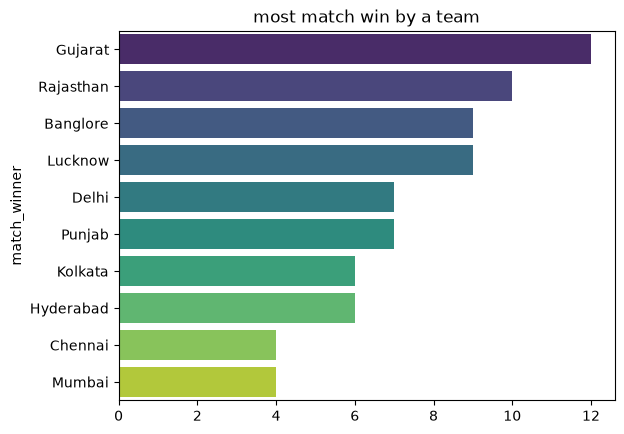

In [131]:
sns.barplot(x=match_wins.values,y=match_wins.index,palette='viridis')
plt.title('most match win by a team')

2. Toss Decision Trends

In [132]:
toss_decision= df['toss_decision'].value_counts()

In [133]:
toss_decision

toss_decision
Field    59
Bat      15
Name: count, dtype: int64

<Axes: xlabel='toss_decision', ylabel='count'>

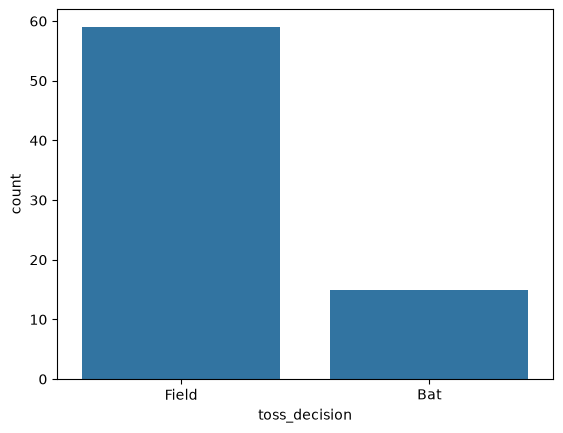

In [134]:
sns.barplot(data=toss_decision)

## using countPlot

Text(0.5, 1.0, 'Toss decision Trends')

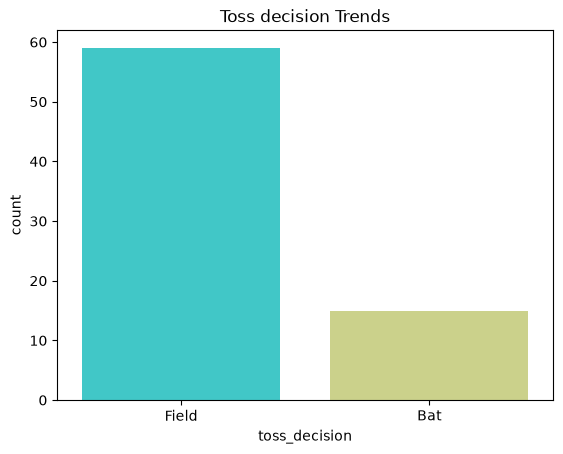

In [135]:
sns.countplot(x=df['toss_decision'],palette='rainbow')
plt.title('Toss decision Trends')

3. Toss winners vs match winners

In [136]:
count = df[df['toss_winner']==df['match_winner']]['match_id'].count()
percentage = (count*100)/df.shape[0]
percentage

np.float64(48.648648648648646)

4.How do teams win? by runs or by wickets

<Axes: xlabel='won_by', ylabel='count'>

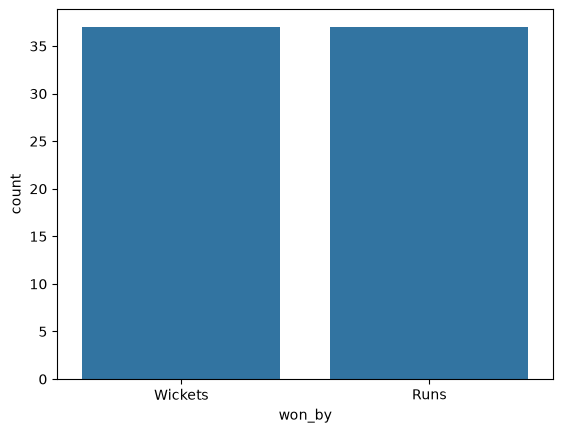

In [137]:
sns.countplot(x=df['won_by'])

### Key player Performances

1.Most player of the match awards

In [138]:
man_of_match = df['player_of_the_match'].value_counts().head(10)
man_of_match

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Umesh Yadav          2
Wanindu Hasaranga    2
Avesh Khan           2
Dinesh Karthik       2
Quinton de Kock      2
Shubman Gill         2
Yuzvendra Chahal     2
Hardik Pandya        2
Name: count, dtype: int64

<Axes: ylabel='player_of_the_match'>

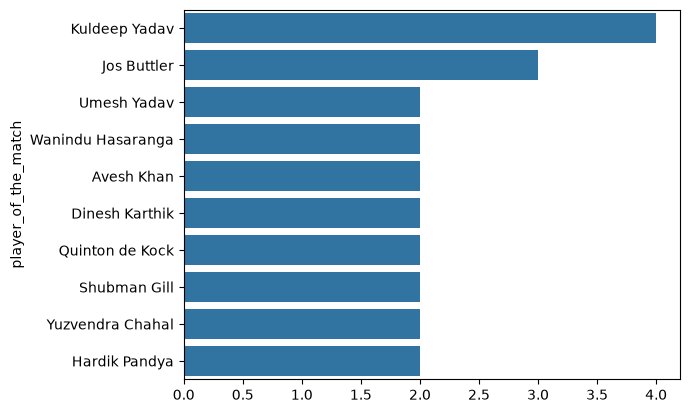

In [139]:
sns.barplot(x= man_of_match.values,y=man_of_match.index)

2.Top scores

In [140]:
high = df.groupby(by='top_scorer')['highscore'].sum().sort_values(ascending=False).head()
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
KL Rahul           351
Shubman Gill       288
Faf du Plessis     257
Name: highscore, dtype: int64

<Axes: ylabel='top_scorer'>

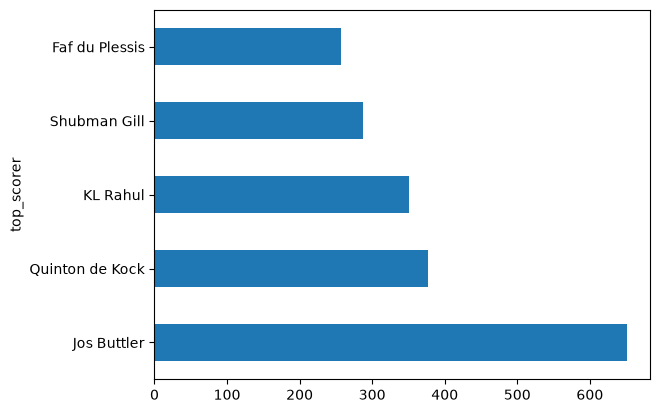

In [141]:
high.plot(kind='barh')

10 best bowling figures

In [142]:
df['highest_wickets']=df['best_bowling_figure'].apply(lambda x:x.split('--')[0])
df['highest_wickets']=df['highest_wickets'].astype(int)


In [143]:
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers

best_bowling
Yuzvendra Chahal     17
Jasprit Bumrah       11
Kuldeep Yadav        11
Rashid Khan          11
Josh Hazlewood       10
Kagiso Rabada        10
Avesh Khan           10
Umran Malik           9
Wanindu Hasaranga     9
T Natarajan           8
Name: highest_wickets, dtype: int64

<Axes: ylabel='best_bowling'>

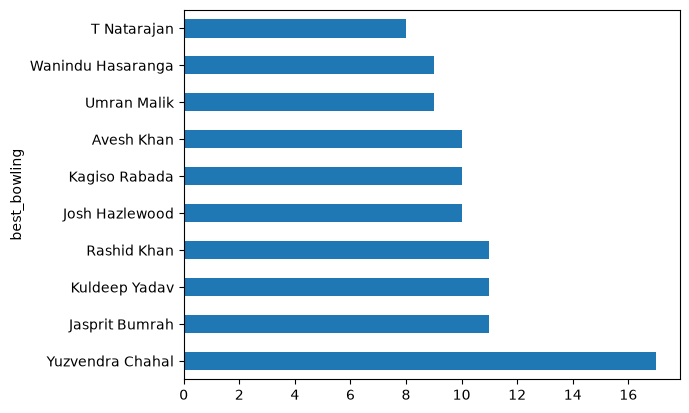

In [144]:
top_bowlers.plot(kind='barh')

#### Venue analysis

most matches played by venue

In [145]:
venue_count = df['venue'].value_counts()
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

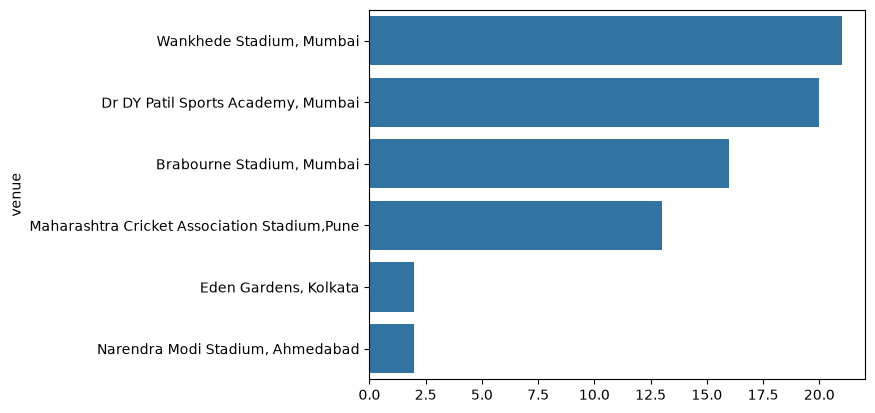

In [146]:
sns.barplot(y=venue_count.index,x=venue_count.values)

### Custom Questions and insights

1.who won th highest margin by runs?

In [147]:
df[df['won_by']=='Runs'].sort_values(by='margin',ascending=False).head(1)['margin']

54    91
Name: margin, dtype: int64

2.which player had the highest individual score?

In [151]:
df[df['highscore']==df['highscore'].max()][['top_scorer','highscore']]


,top_scorer,highscore
65,Quinton de Kock,140


which bowler had the best bowling figure

In [155]:
df[df['highest_wickets']==df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
